# Exploratory Data Analysis (EDA)

**Objective:** Understand the stroke dataset before building models.

This notebook explores:
1. Data structure and quality
2. Data validation (since data are collected from 4 contributors with no prior experience to data collecting, errors can be made)
3. Class distribution and balance
4. Stroke geometry and characteristics
5. Feature distributions and correlations
6. Insights for model design

---

## 1. Setup and Data Loading

In [82]:
import sys
import json
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 20)

print("Setup complete!")

Setup complete!


In [83]:
# Define data paths
DATA_DIR = Path.cwd().parent.parent / "data"

# List all contributor folders
contributor_folders = [d for d in DATA_DIR.iterdir() if d.is_dir()]
print(f"Data directory: {DATA_DIR}")
print(f"\nContributors found: {len(contributor_folders)}")
for folder in contributor_folders:
    files = list(folder.glob('*.json'))
    print(f"  - {folder.name}: {len(files)} files")

Data directory: c:\Users\huybh\documents\onepen\data

Contributors found: 4
  - Contributor_Esh: 13 files
  - Contributor_Linh: 12 files
  - Contributor_Quang: 14 files
  - Contributor_Sang: 15 files


In [84]:
def load_json_file(filepath):
    """Load stroke data from JSON file."""
    with open(filepath, 'r') as f:
        data = json.load(f)
    if isinstance(data, dict):
        return data.get('modifiers', [])
    return data

def load_all_data(data_dir):
    """Load all stroke data with metadata."""
    all_strokes = []
    
    for folder in data_dir.iterdir():
        if not folder.is_dir():
            continue
            
        for json_file in folder.glob('*.json'):
            modifiers = load_json_file(json_file)
            
            for mod in modifiers:
                stroke = mod.get('stroke', [])
                if len(stroke) < 2:
                    continue
                    
                all_strokes.append({
                    'type': mod.get('type', 'unknown'),
                    'stroke': stroke,
                    'contributor': folder.name,
                    'source_file': json_file.stem,
                    'num_points': len(stroke),
                })
    
    return all_strokes

# Load all data
raw_data = load_all_data(DATA_DIR)
print(f"\nTotal strokes loaded: {len(raw_data)}")


Total strokes loaded: 2825


## 2. Data Overview

In [85]:
# Convert to DataFrame for easier analysis
df = pd.DataFrame(raw_data)

print("Dataset Overview")
print("=" * 50)
print(f"Total samples: {len(df)}")
print(f"Unique classes: {df['type'].nunique()}")
print(f"Contributors: {df['contributor'].nunique()}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nSample data:")
df.head()

Dataset Overview
Total samples: 2825
Unique classes: 10
Contributors: 4

Columns: ['type', 'stroke', 'contributor', 'source_file', 'num_points']

Sample data:


,type,stroke,contributor,source_file,num_points
0,box,"[{'x': 847.6635131835938, 'y': 127.76633453369...",Contributor_Esh,boxcircle,95
1,box,"[{'x': 1059.81298828125, 'y': 144.121475219726...",Contributor_Esh,boxcircle,57
2,box,"[{'x': 1227.1026611328125, 'y': 50.66354370117...",Contributor_Esh,boxcircle,55
3,box,"[{'x': 1239.2520751953125, 'y': 149.2616424560...",Contributor_Esh,boxcircle,44
4,box,"[{'x': 1189.252197265625, 'y': 293.65417480468...",Contributor_Esh,boxcircle,54


In [86]:
# Basic statistics
print("\nStroke Point Count Statistics:")
print(df['num_points'].describe())


Stroke Point Count Statistics:
count    2825.000000
mean      132.881062
std       100.337479
min         2.000000
25%        64.000000
50%       110.000000
75%       172.000000
max      1197.000000
Name: num_points, dtype: float64


In [87]:
import plotly.express as px

fig = px.violin(df, y="num_points", box=True, hover_name="num_points")
fig.update_layout(title="Stroke point count statististics")
fig.show()

## 3. Class Distribution Analysis

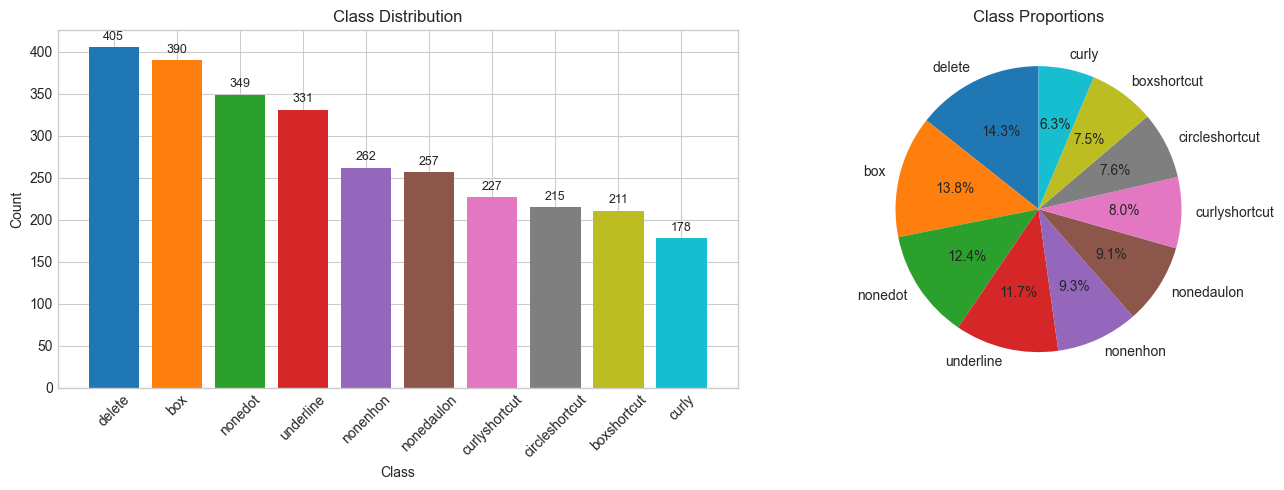


Class Distribution:
----------------------------------------
delete              :   405 ( 14.3%)
box                 :   390 ( 13.8%)
nonedot             :   349 ( 12.4%)
underline           :   331 ( 11.7%)
nonenhon            :   262 (  9.3%)
nonedaulon          :   257 (  9.1%)
curlyshortcut       :   227 (  8.0%)
circleshortcut      :   215 (  7.6%)
boxshortcut         :   211 (  7.5%)
curly               :   178 (  6.3%)

Class imbalance ratio: 2.28:1


In [88]:
# Class distribution
class_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = plt.cm.tab10(np.linspace(0, 1, len(class_counts)))
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution')
axes[0].tick_params(axis='x', rotation=45)

# Add count labels
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 str(count), ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()

# Print statistics
print("\nClass Distribution:")
print("-" * 40)
for cls, count in class_counts.items():
    pct = count / len(df) * 100
    print(f"{cls:20s}: {count:5d} ({pct:5.1f}%)")

# Class imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}:1")

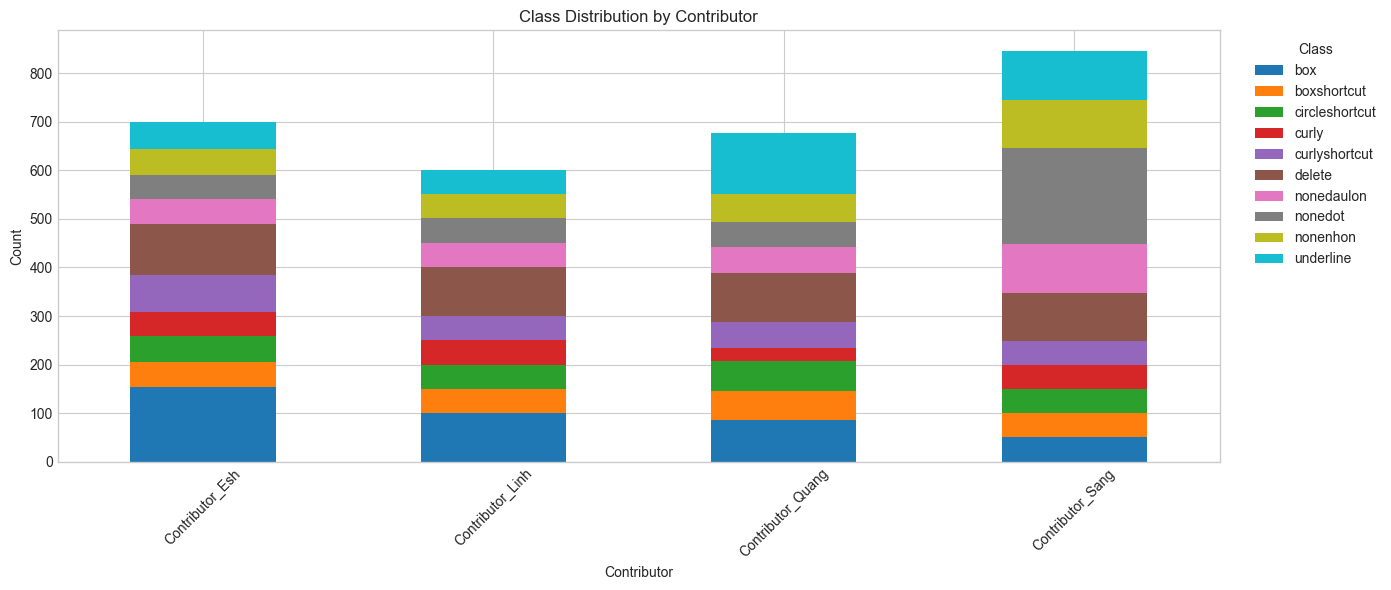


Samples per Contributor:
contributor
Contributor_Sang     846
Contributor_Esh      700
Contributor_Quang    678
Contributor_Linh     601
Name: count, dtype: int64


In [89]:
# Distribution by contributor
contrib_class = pd.crosstab(df['contributor'], df['type'])

fig, ax = plt.subplots(figsize=(14, 6))
contrib_class.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_xlabel('Contributor')
ax.set_ylabel('Count')
ax.set_title('Class Distribution by Contributor')
ax.legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nSamples per Contributor:")
print(df['contributor'].value_counts())

## 4. Stroke Visualization

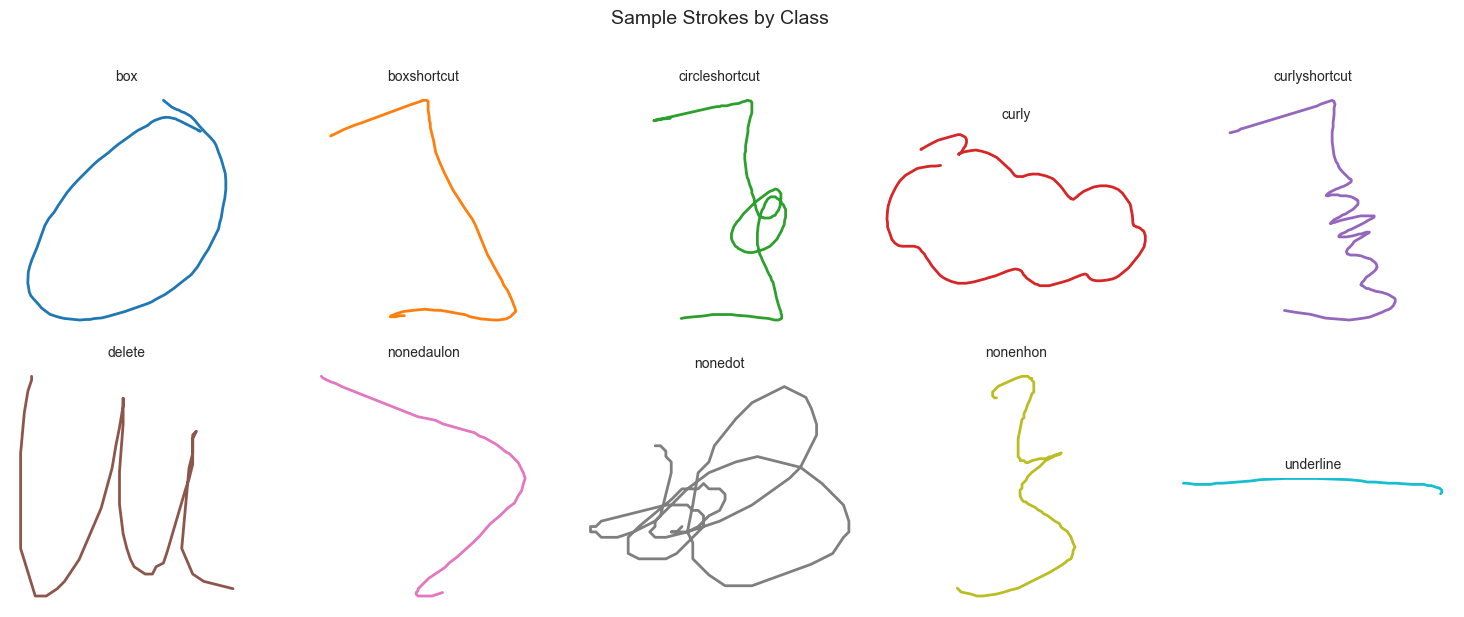

In [90]:
def plot_stroke(stroke, ax, title='', color='blue'):
    """Plot a single stroke."""
    x = [p['x'] for p in stroke]
    y = [p['y'] for p in stroke]
    ax.plot(x, y, color=color, linewidth=2)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

# Get unique classes
classes = df['type'].unique()
n_classes = len(classes)

# Plot samples from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

colors = plt.cm.tab10(np.linspace(0, 1, n_classes))

for idx, cls in enumerate(classes[:10]):
    sample = df[df['type'] == cls].iloc[0]
    plot_stroke(sample['stroke'], axes[idx], title=cls, color=colors[idx])

plt.suptitle('Sample Strokes by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

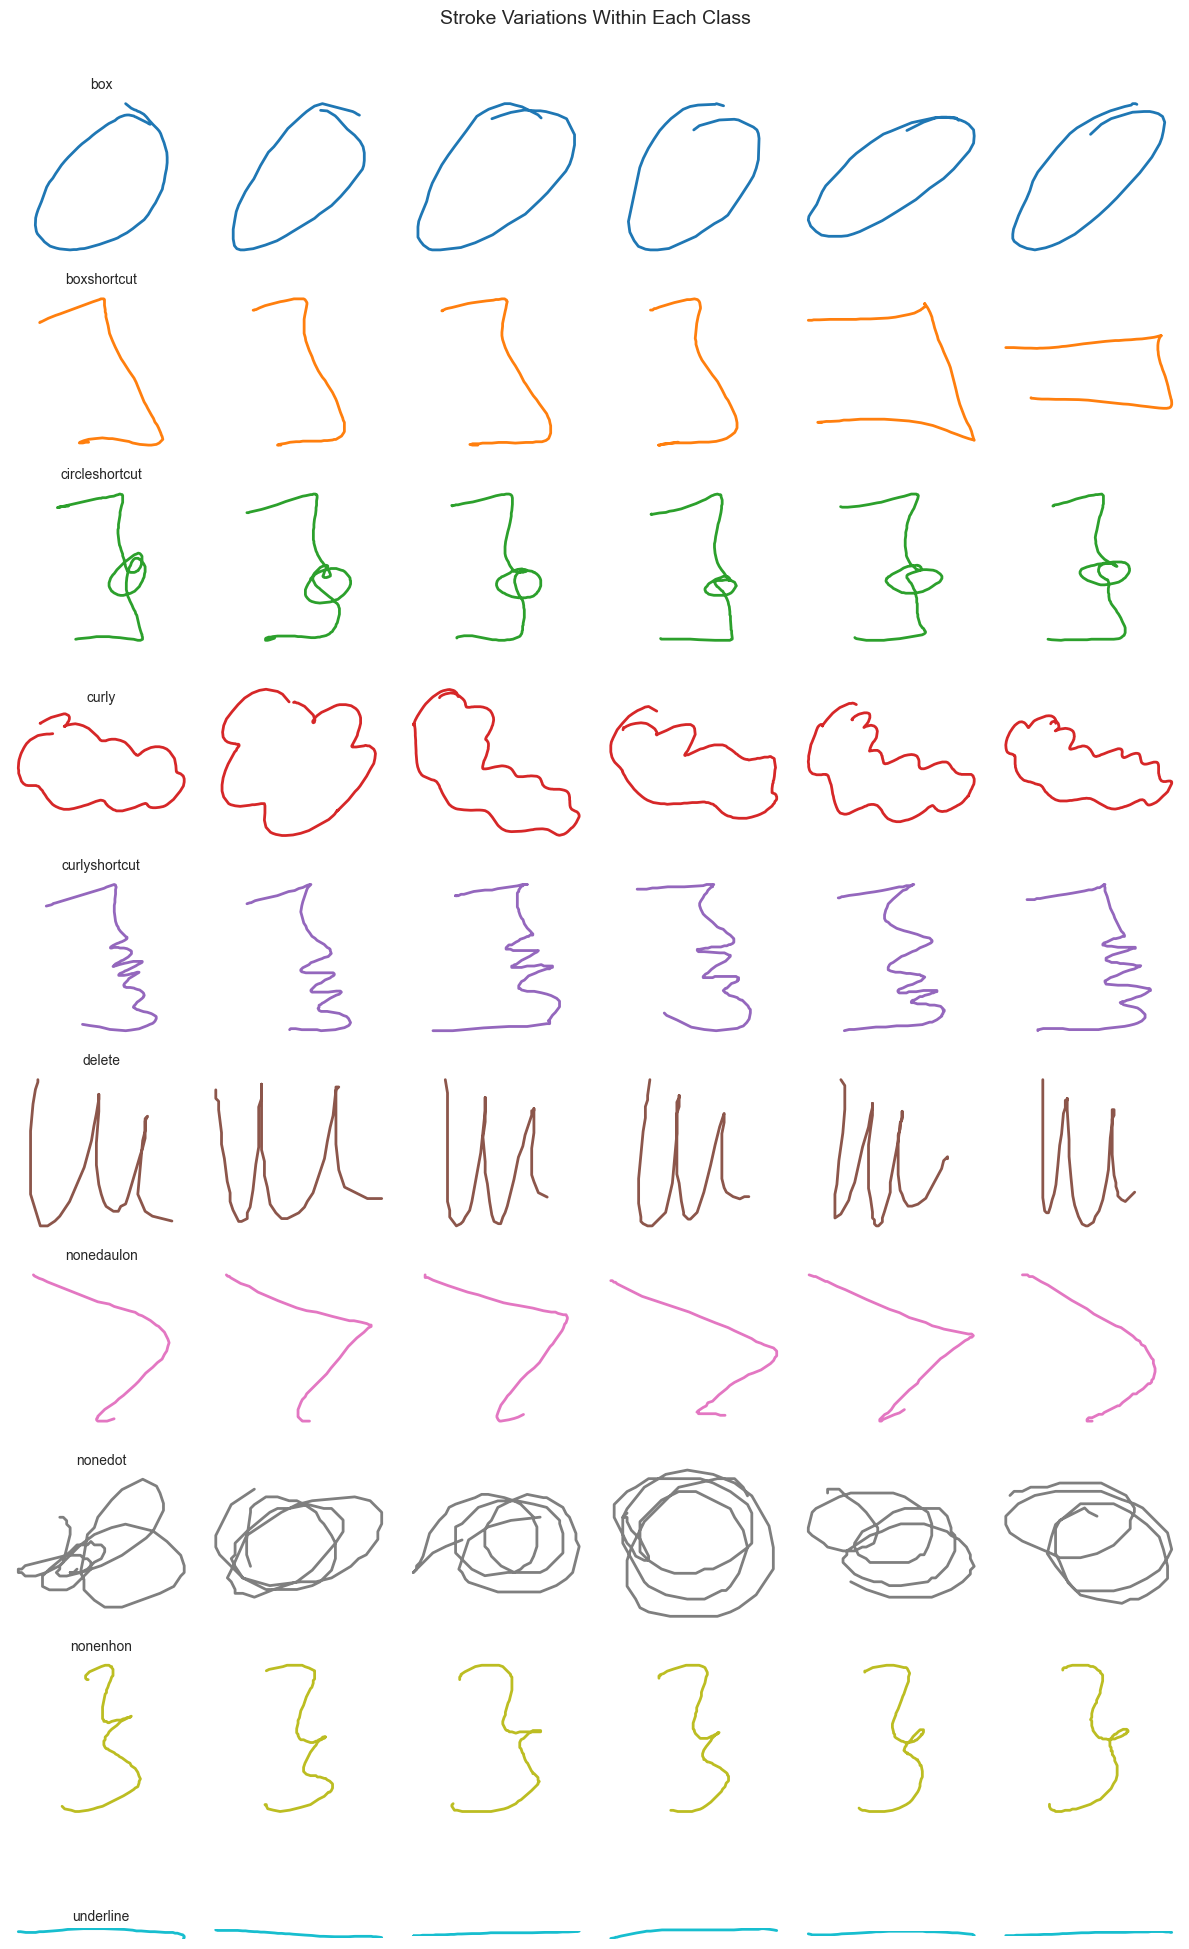

In [91]:
# Visualize multiple samples per class (to see variation)
fig, axes = plt.subplots(len(classes), 6, figsize=(12, len(classes) * 2))

for row, cls in enumerate(classes):
    samples = df[df['type'] == cls].head(6)
    for col, (_, sample) in enumerate(samples.iterrows()):
        plot_stroke(sample['stroke'], axes[row, col], 
                   title=cls if col == 0 else '', color=colors[row])

plt.suptitle('Stroke Variations Within Each Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

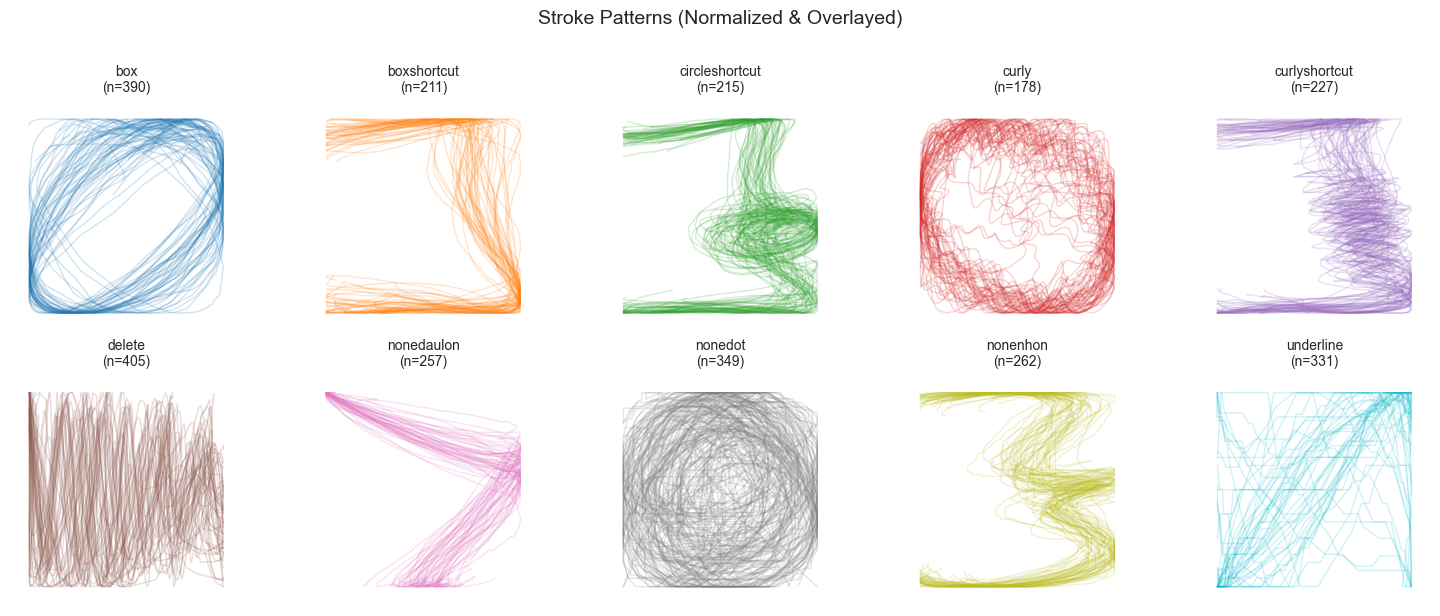

In [92]:
# Overlay all strokes per class (normalized)
def normalize_stroke(stroke):
    """Normalize stroke to [0, 1] range."""
    x = np.array([p['x'] for p in stroke])
    y = np.array([p['y'] for p in stroke])
    
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    
    w = max(x_max - x_min, 1e-6)
    h = max(y_max - y_min, 1e-6)
    
    return (x - x_min) / w, (y - y_min) / h

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, cls in enumerate(classes[:10]):
    class_strokes = df[df['type'] == cls]['stroke'].values
    
    for stroke in class_strokes[:50]:  # Limit for clarity
        x_norm, y_norm = normalize_stroke(stroke)
        axes[idx].plot(x_norm, y_norm, color=colors[idx], alpha=0.2, linewidth=1)
    
    axes[idx].invert_yaxis()
    axes[idx].set_xlim(-0.1, 1.1)
    axes[idx].set_ylim(1.1, -0.1)
    axes[idx].set_aspect('equal')
    axes[idx].set_title(f'{cls}\n(n={len(class_strokes)})', fontsize=10)
    axes[idx].axis('off')

plt.suptitle('Stroke Patterns (Normalized & Overlayed)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Geometric Feature Analysis

This section explores geometric features that could be useful for stroke classification. We'll compute a comprehensive set of features and then use statistical methods to determine which ones are most valuable for the model.

**Candidate Features:**
- **Shape features:** aspect ratio, compactness, direction bias
- **Size features:** width, height, total length, diagonal
- **Complexity features:** curvature, rectilinearity, point density
- **Position features:** edge fraction, spine verticality, closure ratio
- **Statistical features:** variance in x/y coordinates

Later, we'll use feature selection techniques to determine the optimal subset.

In [93]:
def compute_all_geometric_features(stroke, height_threshold=45, cap_value=100):
    """Compute comprehensive geometric features for exploration.
    
    Returns dict with all candidate features for analysis.
    """
    if len(stroke) < 2:
        return None
    
    # Extract coordinates
    pts = np.array([[p['x'], p['y']] for p in stroke])
    x, y = pts[:, 0], pts[:, 1]
    n_points = len(pts)
    
    # Bounding box
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    width = max(x_max - x_min, 1e-6)
    height = max(y_max - y_min, 1e-6)
    bbox_area = width * height
    diag = np.sqrt(width**2 + height**2)
    
    # Segment calculations
    deltas = np.diff(pts, axis=0)
    seg_lengths = np.linalg.norm(deltas, axis=1)
    total_len = np.sum(seg_lengths)
    
    # Normalized coordinates
    x_norm = (x - x_min) / width
    y_norm = (y - y_min) / height
    
    # ============== SHAPE FEATURES ==============
    
    # Perimeter to diagonal ratio
    perim_diag_ratio = (2 * (width + height)) / (diag + 1e-6)
    
    # Direction bias: |w-h|/(w+h) - bounded [0,1], 0=square, 1=line
    direction_bias = abs(width - height) / (width + height + 1e-6)
    
    # Aspect ratio bounded using atan: 2*atan(w/h)/pi - bounded [0,1], 0.5=square
    aspect_ratio = 2 * np.arctan(width / height) / np.pi
    
    # Compactness: path length / diagonal (how "squiggly" is the stroke)
    compactness = total_len / (diag + 1e-6)
    
    # ============== SIZE FEATURES ==============
    
    # Raw dimensions (will need normalization for model)
    raw_width = width
    raw_height = height
    raw_total_len = total_len
    
    # Height difference from threshold (normalized)
    height_diff = np.clip((height - height_threshold) / cap_value, -1.0, 1.0)
    
    # ============== COMPLEXITY FEATURES ==============
    
    # Average curvature (angle change between segments)
    avg_curvature = 0.0
    max_curvature = 0.0
    if len(deltas) > 1:
        angles = np.arctan2(deltas[:, 1], deltas[:, 0])
        angle_diffs = np.abs(np.diff(angles))
        angle_diffs = np.minimum(angle_diffs, 2 * np.pi - angle_diffs)
        avg_curvature = np.mean(angle_diffs)
        max_curvature = np.max(angle_diffs)
    
    # Rectilinearity: fraction of ~straight or ~90° segments
    rectilinearity = 0.0
    if len(deltas) > 1:
        angles = np.arctan2(deltas[:, 1], deltas[:, 0])
        angle_diffs = np.abs(np.diff(angles))
        angle_diffs = np.minimum(angle_diffs, np.pi - angle_diffs)
        rect_count = np.sum((angle_diffs < 0.2) | (np.abs(angle_diffs - np.pi / 2) < 0.2))
        rectilinearity = rect_count / len(angle_diffs)
    
    # Point density (log scale)
    density = n_points / (bbox_area + 1e-6)
    log_density = np.log1p(density)
    
    # Points per unit length
    points_per_length = n_points / (total_len + 1e-6)
    
    # ============== POSITION FEATURES ==============
    
    # Edge fraction: how many points are near the bounding box edges
    edge_thresh = 0.1
    d_edge = np.minimum.reduce([x_norm, 1 - x_norm, y_norm, 1 - y_norm])
    edge_frac = np.mean(d_edge < edge_thresh)
    
    # Spine verticality: how vertical is start-to-end direction (0=horizontal, 1=vertical)
    dx_spine = x[-1] - x[0]
    dy_spine = y[-1] - y[0]
    spine_angle = abs(np.arctan2(dy_spine, dx_spine))
    spine_verticality = 1 - abs(spine_angle - np.pi / 2) / (np.pi / 2)
    
    # Overall direction in degrees
    direction_deg = np.arctan2(dy_spine, dx_spine) * 180 / np.pi
    
    # Closure ratio: how close is end to start (1=closed loop, 0=open)
    end_to_start = np.sqrt((x[-1] - x[0])**2 + (y[-1] - y[0])**2)
    closure_ratio = 1 - min(end_to_start / (diag + 1e-6), 1.0)
    
    # ============== STATISTICAL FEATURES ==============
    
    # Variance in coordinates
    horiz_var = np.std(x)
    vert_var = np.std(y)
    
    # Center of mass position (normalized)
    center_x = np.mean(x_norm)
    center_y = np.mean(y_norm)
    
    # Spread ratio (how spread out vs concentrated)
    spread = np.std(np.linalg.norm(pts - pts.mean(axis=0), axis=1))
    spread_ratio = spread / (diag + 1e-6)
    
    return {
        # Shape features
        'perim_diag_ratio': perim_diag_ratio,
        'direction_bias': direction_bias,
        'aspect_ratio': aspect_ratio,
        'compactness': compactness,
        # Size features
        'width': raw_width,
        'height': raw_height,
        'total_len': total_len,
        'height_diff': height_diff,
        # Complexity features
        'avg_curvature': avg_curvature,
        'max_curvature': max_curvature,
        'rectilinearity': rectilinearity,
        'log_density': log_density,
        'points_per_length': points_per_length,
        # Position features
        'edge_frac': edge_frac,
        'spine_verticality': spine_verticality,
        'direction_deg': direction_deg,
        'closure_ratio': closure_ratio,
        # Statistical features
        'horiz_var': horiz_var,
        'vert_var': vert_var,
        'center_x': center_x,
        'center_y': center_y,
        'spread_ratio': spread_ratio,
        # Meta
        'num_points': n_points,
    }

# Compute features for all strokes
features_list = []
for _, row in df.iterrows():
    feats = compute_all_geometric_features(row['stroke'])
    if feats:
        feats['type'] = row['type']
        feats['contributor'] = row['contributor']
        features_list.append(feats)

features_df = pd.DataFrame(features_list)

# All numeric features for analysis
all_features = [col for col in features_df.columns if col not in ['type', 'contributor']]

print(f"Computed {len(all_features)} candidate features for {len(features_df)} strokes")
print(f"\nFeature categories:")
print(f"  Shape:      perim_diag_ratio, direction_bias, aspect_ratio, compactness")
print(f"  Size:       width, height, total_len, height_diff")
print(f"  Complexity: avg_curvature, max_curvature, rectilinearity, log_density, points_per_length")
print(f"  Position:   edge_frac, spine_verticality, direction_deg, closure_ratio")
print(f"  Statistical: horiz_var, vert_var, center_x, center_y, spread_ratio, num_points")
features_df.head()

Computed 23 candidate features for 2825 strokes

Feature categories:
  Shape:      perim_diag_ratio, direction_bias, aspect_ratio, compactness
  Size:       width, height, total_len, height_diff
  Complexity: avg_curvature, max_curvature, rectilinearity, log_density, points_per_length
  Position:   edge_frac, spine_verticality, direction_deg, closure_ratio
  Statistical: horiz_var, vert_var, center_x, center_y, spread_ratio, num_points


,perim_diag_ratio,direction_bias,aspect_ratio,compactness,width,height,total_len,height_diff,avg_curvature,max_curvature,...,direction_deg,closure_ratio,horiz_var,vert_var,center_x,center_y,spread_ratio,num_points,type,contributor
0,2.824632,0.051852,0.467019,2.256417,179.439087,199.065414,604.725701,1.000000,0.151420,1.570796,...,-140.194569,0.836584,59.393112,68.992957,0.585993,0.462342,0.079614,95,box,Contributor_Esh
1,2.824204,0.054705,0.465208,2.312409,100.934509,112.616821,349.704166,0.676168,0.147276,0.574310,...,-172.874984,0.800705,35.997444,39.099045,0.535900,0.480527,0.084405,57,box,Contributor_Esh
2,2.826782,0.034120,0.521713,2.435085,92.056030,85.981308,306.734625,0.409813,0.152583,0.680532,...,179.075962,0.769970,30.060454,32.041140,0.503553,0.421937,0.082364,55,box,Contributor_Esh
3,2.823937,0.056411,0.464125,2.341814,85.981079,96.261658,302.257785,0.512617,0.200808,0.755125,...,141.008710,0.804363,27.848716,34.565793,0.520011,0.441527,0.077476,44,box,Contributor_Esh
4,2.790893,0.164556,0.603829,2.390395,128.971802,92.523438,379.420606,0.475234,0.164997,0.626959,...,168.818219,0.741919,44.655713,34.655883,0.554348,0.382810,0.108086,54,box,Contributor_Esh


In [94]:
# Feature statistics overview
print("=" * 80)
print("FEATURE STATISTICS SUMMARY")
print("=" * 80)
print(features_df[all_features].describe().round(4))

# Check for any problematic values
print("\n" + "=" * 80)
print("DATA QUALITY CHECK")
print("=" * 80)
print(f"\nMissing values: {features_df[all_features].isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(features_df[all_features].values).sum()}")

# Check value ranges
print("\nFeature value ranges:")
for feat in all_features:
    min_val = features_df[feat].min()
    max_val = features_df[feat].max()
    bounded = "bounded" if (min_val >= -10 and max_val <= 1000) else "UNBOUNDED - may need scaling"
    print(f"  {feat:20s}: [{min_val:10.2f}, {max_val:10.2f}] - {bounded}")

FEATURE STATISTICS SUMMARY
       perim_diag_ratio  direction_bias  aspect_ratio  compactness      width  \
count         2825.0000       2825.0000     2825.0000    2825.0000  2825.0000   
mean             2.6576          0.3073        0.5506       2.7216   126.3503   
std              0.2209          0.2598        0.2186       1.6659   112.3116   
min              2.0000          0.0000        0.0677       1.0000     0.3297   
25%              2.6051          0.1059        0.3897       1.5959    47.1962   
50%              2.7519          0.2375        0.5300       2.3124    92.0559   
75%              2.8127          0.4228        0.6900       3.1983   171.4953   
max              2.8284          1.0000        1.0000      12.9695   970.0934   

          height  total_len  height_diff  avg_curvature  max_curvature  ...  \
count  2825.0000  2825.0000    2825.0000      2825.0000      2825.0000  ...   
mean     94.9876   422.4183       0.3530         0.6428         2.4632  ...   
std   

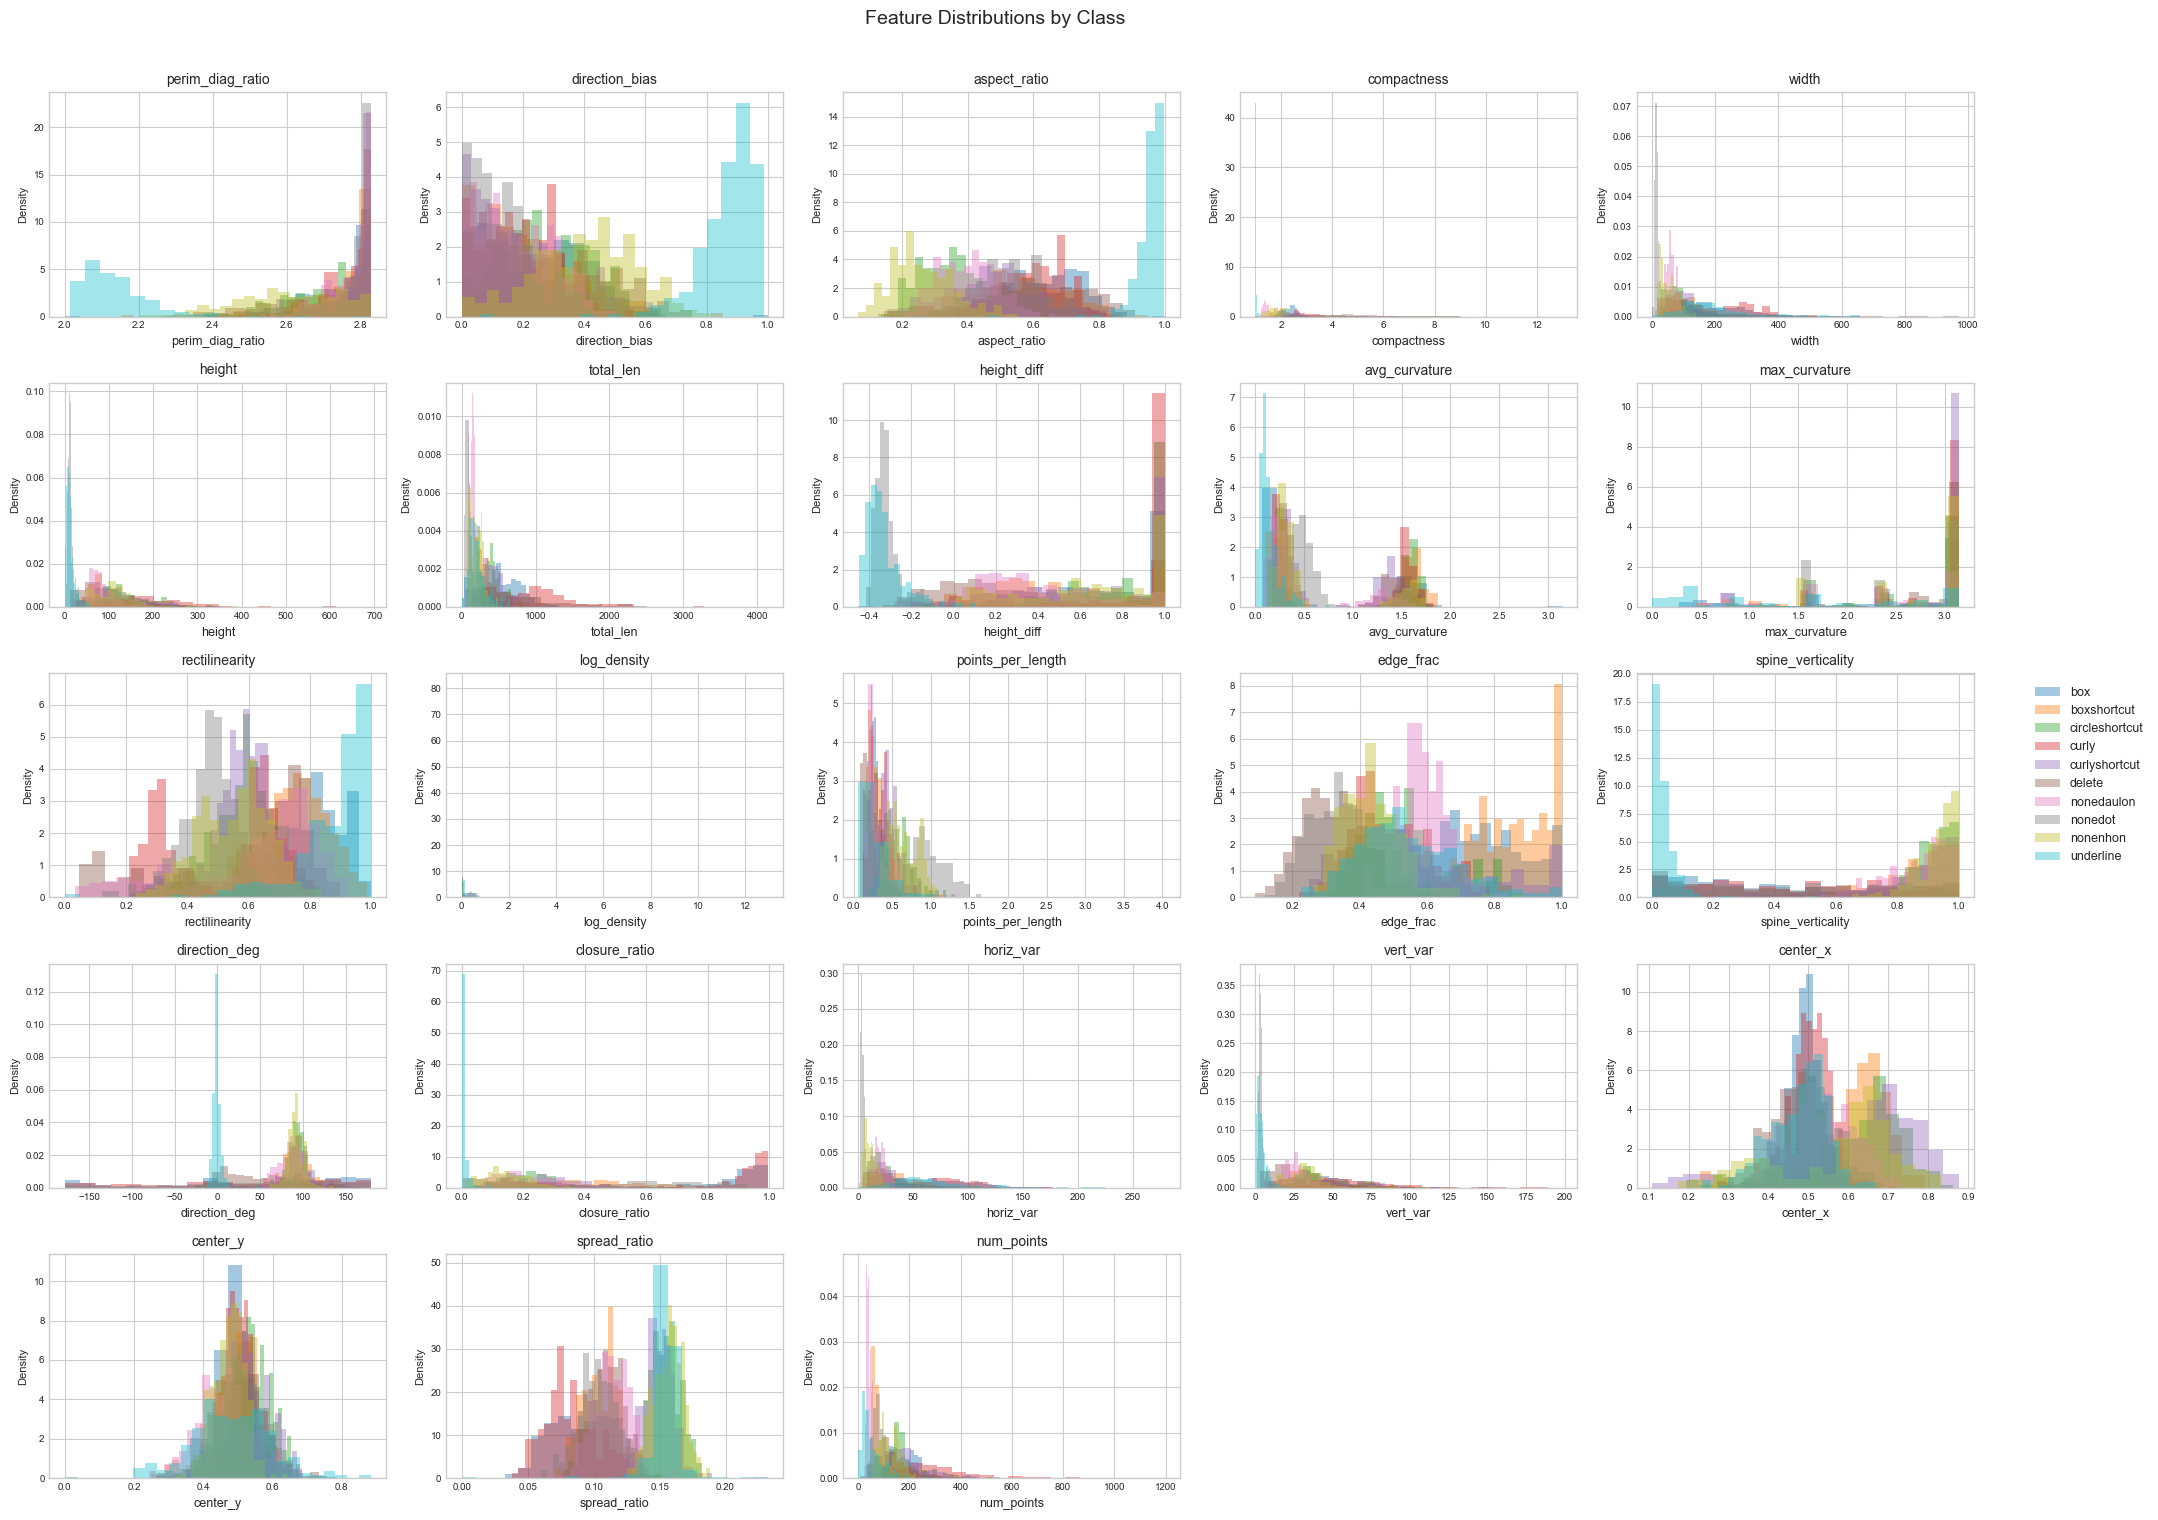

In [95]:
# Feature distributions by class - Grid of all features
n_features = len(all_features)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for idx, feat in enumerate(all_features):
    ax = axes[idx]
    for cls_idx, cls in enumerate(classes):
        data = features_df[features_df['type'] == cls][feat]
        ax.hist(data, bins=20, alpha=0.4, label=cls, density=True, color=colors[cls_idx])
    
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Density', fontsize=8)
    ax.set_title(f'{feat}', fontsize=10)
    ax.tick_params(labelsize=7)

# Hide unused subplots
for idx in range(len(all_features), len(axes)):
    axes[idx].set_visible(False)

# Add single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.08, 0.5), fontsize=9)

plt.suptitle('Feature Distributions by Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

perim_diag_ratio, direction_bias, aspect_ratio, height_diff, avg_culvature, max_curvature, rectilinearity, spine_verticality, edge_frac, direction_deg can be used since their distribution is relatively distinctive by class

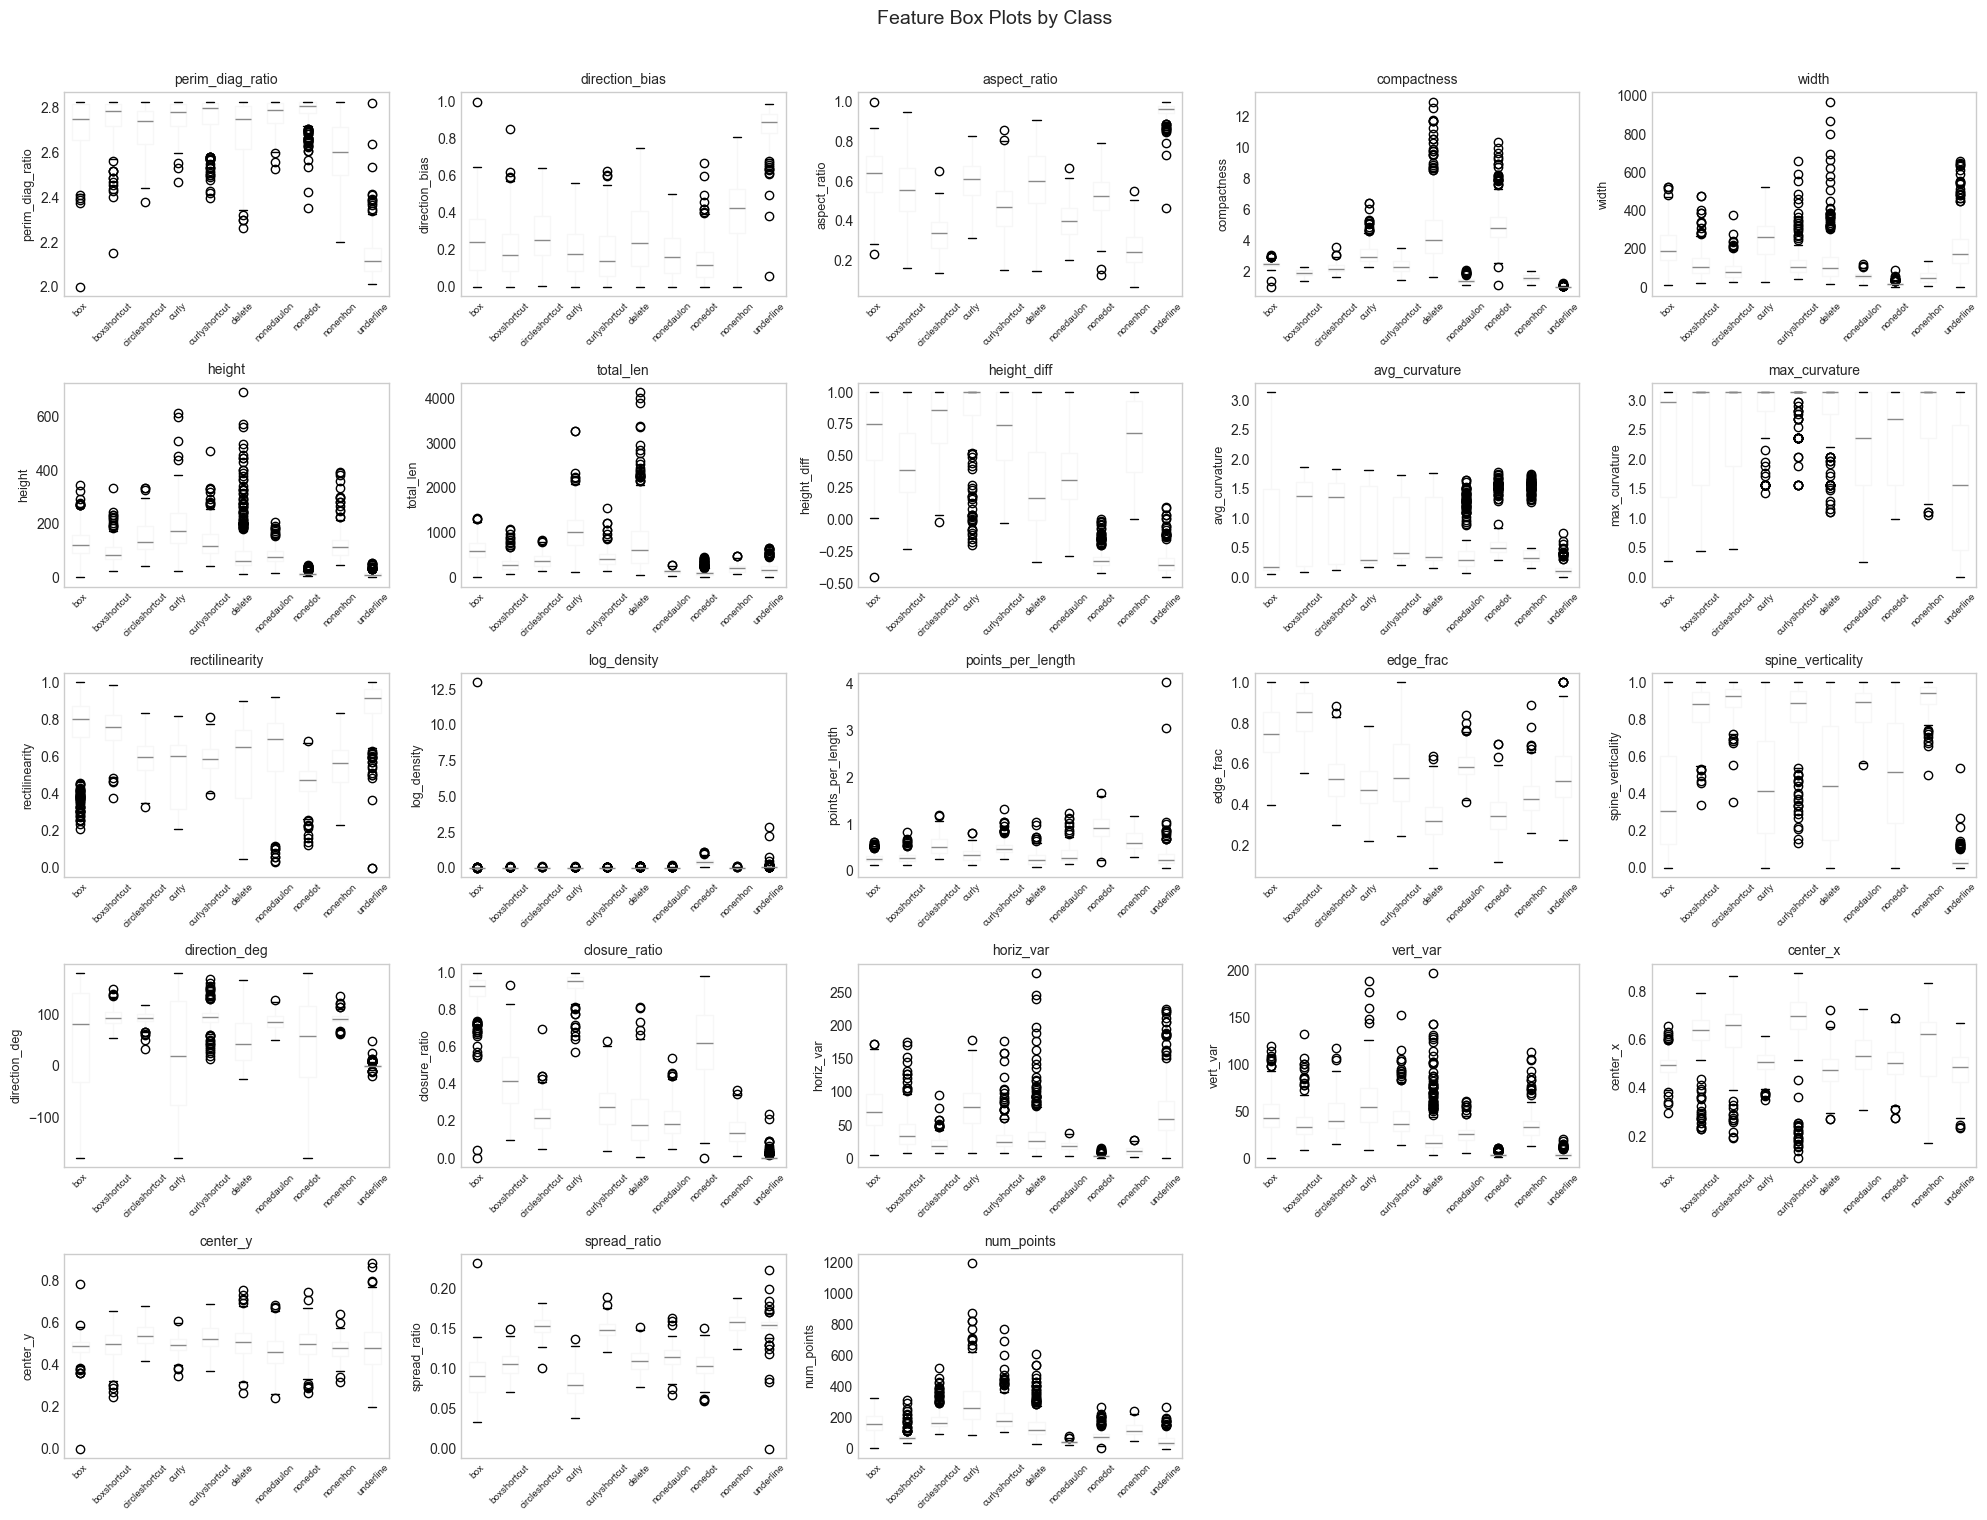

In [96]:
# Box plots for all features by class
n_features = len(all_features)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for idx, feat in enumerate(all_features):
    features_df.boxplot(column=feat, by='type', ax=axes[idx], grid=False)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel(feat, fontsize=9)
    axes[idx].set_title(feat, fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45, labelsize=7)

# Hide unused subplots
for idx in range(len(all_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Feature Box Plots by Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

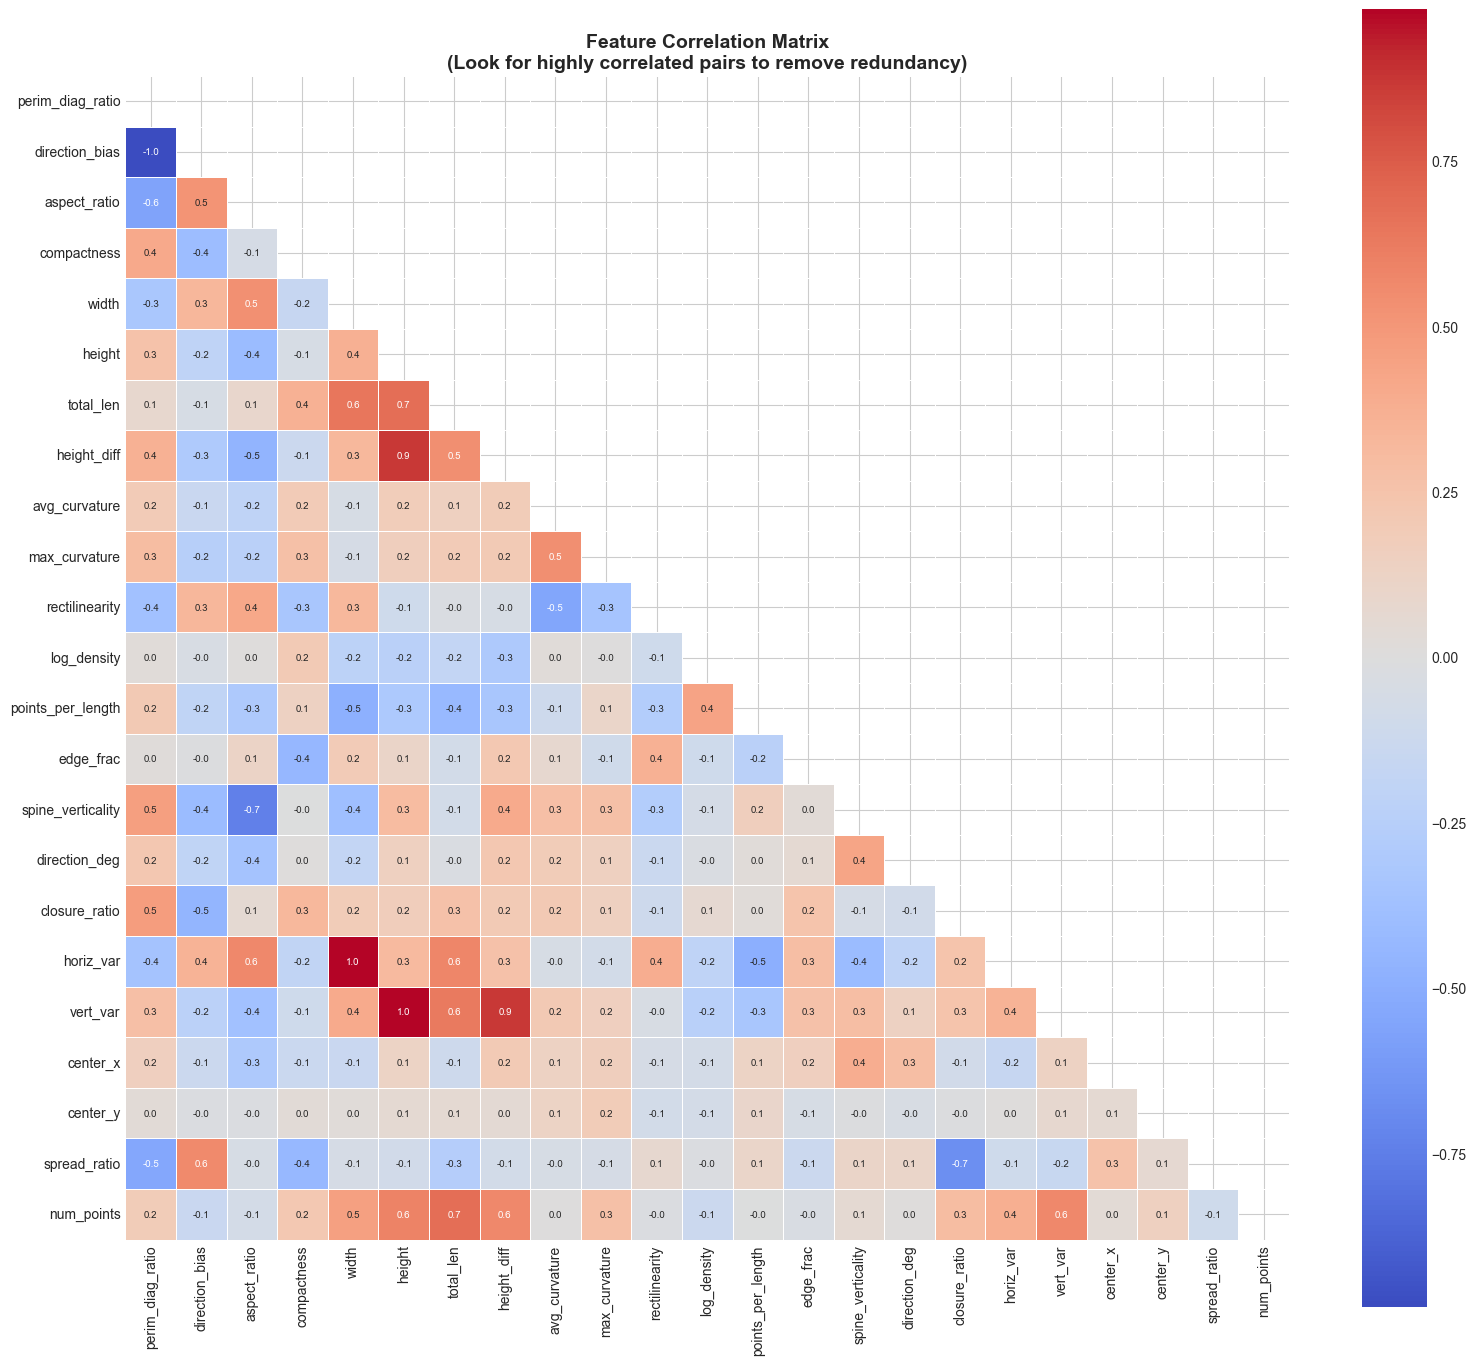

HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7)
Consider removing one from each pair to reduce redundancy
  perim_diag_ratio     <-> direction_bias      : r = -0.981
  aspect_ratio         <-> spine_verticality   : r = -0.740
  width                <-> horiz_var           : r = +0.979
  height               <-> height_diff         : r = +0.864
  height               <-> vert_var            : r = +0.975
  height_diff          <-> vert_var            : r = +0.871

  Total: 6 highly correlated pairs


In [97]:
# Feature correlation matrix
corr_matrix = features_df[all_features].corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.1f', 
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix\n(Look for highly correlated pairs to remove redundancy)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify highly correlated feature pairs (candidates for removal)
print("=" * 70)
print("HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7)")
print("Consider removing one from each pair to reduce redundancy")
print("=" * 70)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], r))
            print(f"  {corr_matrix.columns[i]:20s} <-> {corr_matrix.columns[j]:20s}: r = {r:+.3f}")

if not high_corr_pairs:
    print("  No highly correlated pairs found")
else:
    print(f"\n  Total: {len(high_corr_pairs)} highly correlated pairs")

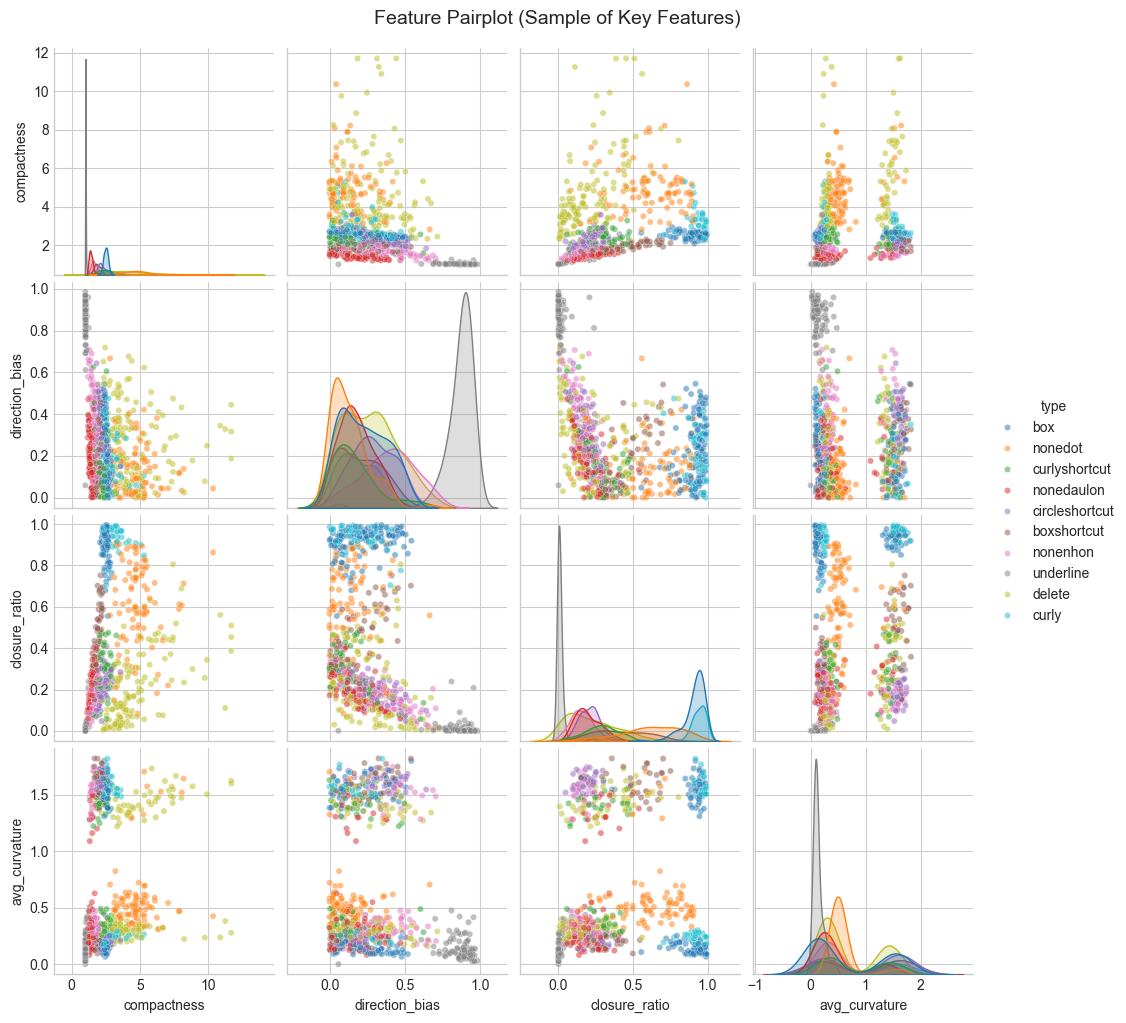

In [98]:
# Pairplot for a subset of interesting features
sample_df = features_df.sample(min(800, len(features_df)), random_state=42)

# Select diverse features from different categories
pairplot_features = ['compactness', 'direction_bias', 'closure_ratio', 'avg_curvature']

g = sns.pairplot(sample_df, vars=pairplot_features,
                 hue='type', diag_kind='kde', 
                 plot_kws={'alpha': 0.5, 's': 20},
                 palette='tab10')
g.fig.suptitle('Feature Pairplot (Sample of Key Features)', y=1.02, fontsize=14)
plt.show()

## 7. Feature Selection: Choosing the Best Features

**Key Question:** Should we use all 23 features, or select a subset?

### Industry Standard Approaches:

1. **Filter Methods** (fast, model-agnostic)
   - ANOVA F-test: measures class separation
   - Mutual Information: captures non-linear dependencies
   - Correlation analysis: remove redundant features

2. **Wrapper Methods** (model-dependent)
   - Recursive Feature Elimination (RFE): iteratively removes worst features
   - Forward/Backward Selection: greedily add/remove features

3. **Embedded Methods** (during training)
   - L1 Regularization (Lasso): automatically zeros out useless features
   - Tree-based importance: Random Forest, XGBoost

### Guidelines for Number of Features:
- **Rule of thumb:** 10-20 samples per feature minimum
- **Your dataset:** ~2800 samples → can support 15-25 features
- **But more isn't always better:** redundant features add noise
- **Sweet spot:** Usually 5-15 well-chosen features outperform 50+ noisy ones

ANOVA F-TEST: FEATURE DISCRIMINATIVE POWER
Higher F-score = better class separation
  closure_ratio         : F=  1846.0 ██████████████████████████████ ***
  perim_diag_ratio      : F=  1159.9 ██████████████████████████████ ***
  spread_ratio          : F=   883.0 ██████████████████████████████ ***
  aspect_ratio          : F=   786.5 ██████████████████████████████ ***
  direction_bias        : F=   697.2 ██████████████████████████████ ***
  height_diff           : F=   674.2 ██████████████████████████████ ***
  compactness           : F=   652.1 ██████████████████████████████ ***
  edge_frac             : F=   521.3 ██████████████████████████████ ***
  spine_verticality     : F=   507.5 ██████████████████████████████ ***
  points_per_length     : F=   351.1 ██████████████████████████████ ***
  vert_var              : F=   287.3 ████████████████████████████ ***
  num_points            : F=   284.6 ████████████████████████████ ***
  horiz_var             : F=   279.7 ███████████████████

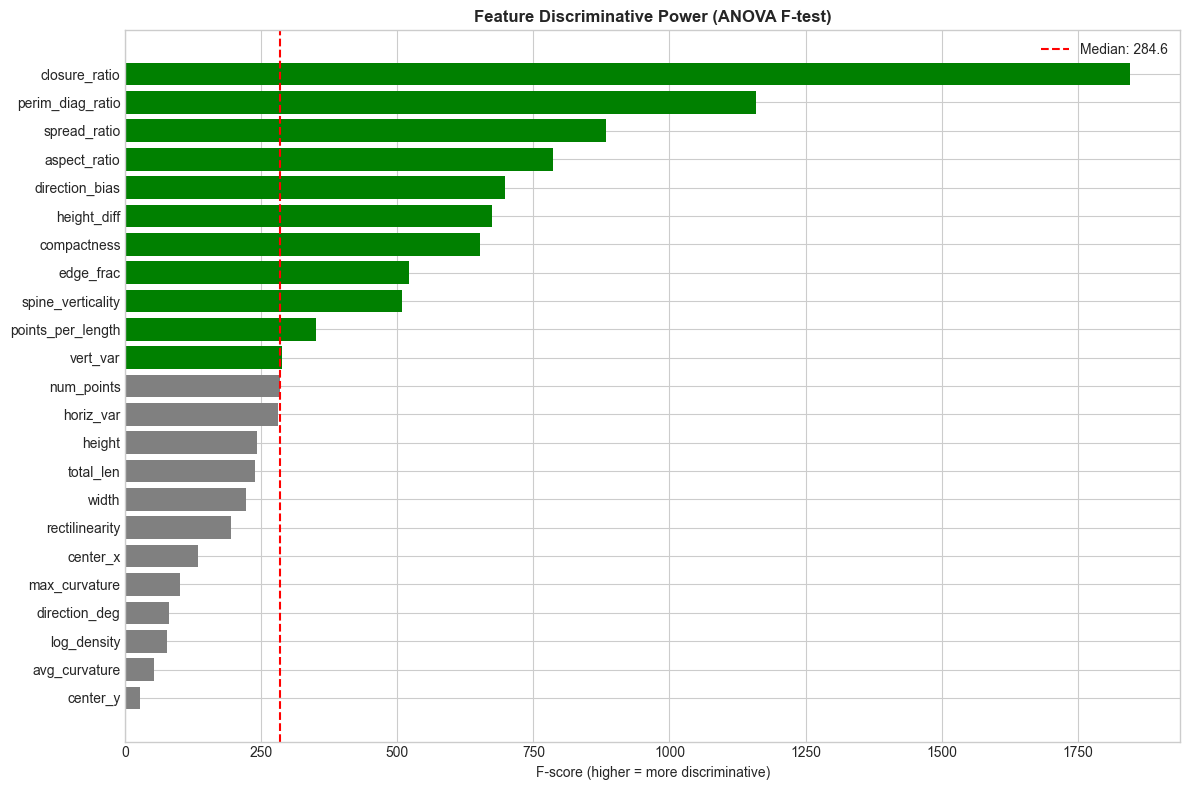

In [99]:
# ANOVA F-test for all features
from scipy.stats import f_oneway

f_scores = {}
for feat in all_features:
    groups = [features_df[features_df['type'] == cls][feat].dropna().values for cls in classes]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        f_stat, p_val = f_oneway(*groups)
        f_scores[feat] = {'F-score': f_stat, 'p-value': p_val}

f_df = pd.DataFrame(f_scores).T.sort_values('F-score', ascending=False)

print("=" * 70)
print("ANOVA F-TEST: FEATURE DISCRIMINATIVE POWER")
print("Higher F-score = better class separation")
print("=" * 70)

for feat in f_df.index:
    f_val = f_df.loc[feat, 'F-score']
    p_val = f_df.loc[feat, 'p-value']
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    bar = "█" * min(int(f_val / 10), 30)
    print(f"  {feat:22s}: F={f_val:8.1f} {bar} {sig}")

# Visualize
plt.figure(figsize=(12, 8))
f_sorted = f_df.sort_values('F-score', ascending=True)
colors_bar = ['green' if f > f_df['F-score'].median() else 'gray' for f in f_sorted['F-score']]
plt.barh(f_sorted.index, f_sorted['F-score'], color=colors_bar)
plt.axvline(x=f_df['F-score'].median(), color='red', linestyle='--', label=f'Median: {f_df["F-score"].median():.1f}')
plt.xlabel('F-score (higher = more discriminative)')
plt.title('Feature Discriminative Power (ANOVA F-test)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

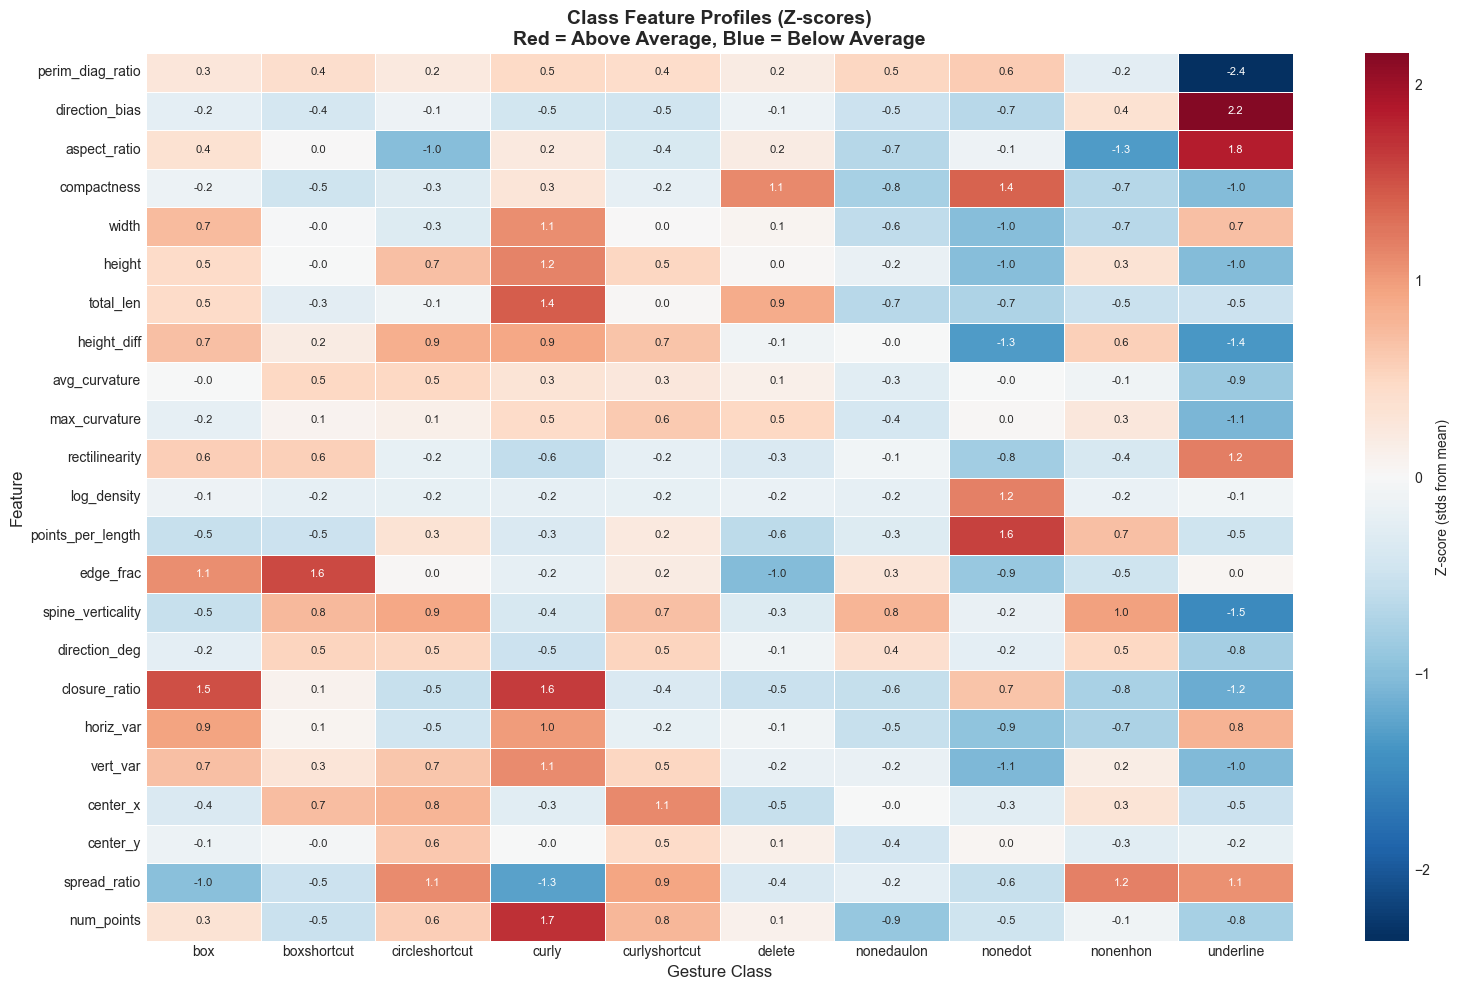

DISTINCTIVE FEATURES PER CLASS (|z| > 0.5)

BOX:
  - closure_ratio: HIGH (z=+1.52)
  - edge_frac: HIGH (z=+1.09)
  - spread_ratio: LOW (z=-0.98)
  - horiz_var: HIGH (z=+0.95)
  - width: HIGH (z=+0.74)

BOXSHORTCUT:
  - edge_frac: HIGH (z=+1.55)
  - spine_verticality: HIGH (z=+0.76)
  - center_x: HIGH (z=+0.72)
  - rectilinearity: HIGH (z=+0.56)
  - direction_deg: HIGH (z=+0.52)

CIRCLESHORTCUT:
  - spread_ratio: HIGH (z=+1.10)
  - aspect_ratio: LOW (z=-0.99)
  - spine_verticality: HIGH (z=+0.91)
  - height_diff: HIGH (z=+0.87)
  - center_x: HIGH (z=+0.79)

CURLY:
  - num_points: HIGH (z=+1.73)
  - closure_ratio: HIGH (z=+1.63)
  - total_len: HIGH (z=+1.43)
  - spread_ratio: LOW (z=-1.27)
  - height: HIGH (z=+1.16)

CURLYSHORTCUT:
  - center_x: HIGH (z=+1.13)
  - spread_ratio: HIGH (z=+0.93)
  - num_points: HIGH (z=+0.78)
  - spine_verticality: HIGH (z=+0.70)
  - height_diff: HIGH (z=+0.67)

DELETE:
  - compactness: HIGH (z=+1.13)
  - edge_frac: LOW (z=-1.02)
  - total_len: HIGH (z=+0.8

In [100]:
# Per-class feature profiles
class_means = features_df.groupby('type')[all_features].mean()
global_means = features_df[all_features].mean()
global_stds = features_df[all_features].std()

# Standardized class profiles (z-scores)
class_z_scores = (class_means - global_means) / (global_stds + 1e-6)

# Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(class_z_scores.T, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Z-score (stds from mean)'}, 
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Class Feature Profiles (Z-scores)\nRed = Above Average, Blue = Below Average', 
          fontsize=14, fontweight='bold')
plt.xlabel('Gesture Class', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# Print distinctive features per class
print("=" * 70)
print("DISTINCTIVE FEATURES PER CLASS (|z| > 0.5)")
print("=" * 70)
for cls in classes:
    distinctive = class_z_scores.loc[cls][abs(class_z_scores.loc[cls]) > 0.5].sort_values(key=abs, ascending=False)
    if len(distinctive) > 0:
        print(f"\n{cls.upper()}:")
        for feat, z in distinctive.head(5).items():
            direction = "HIGH" if z > 0 else "LOW"
            print(f"  - {feat}: {direction} (z={z:+.2f})")

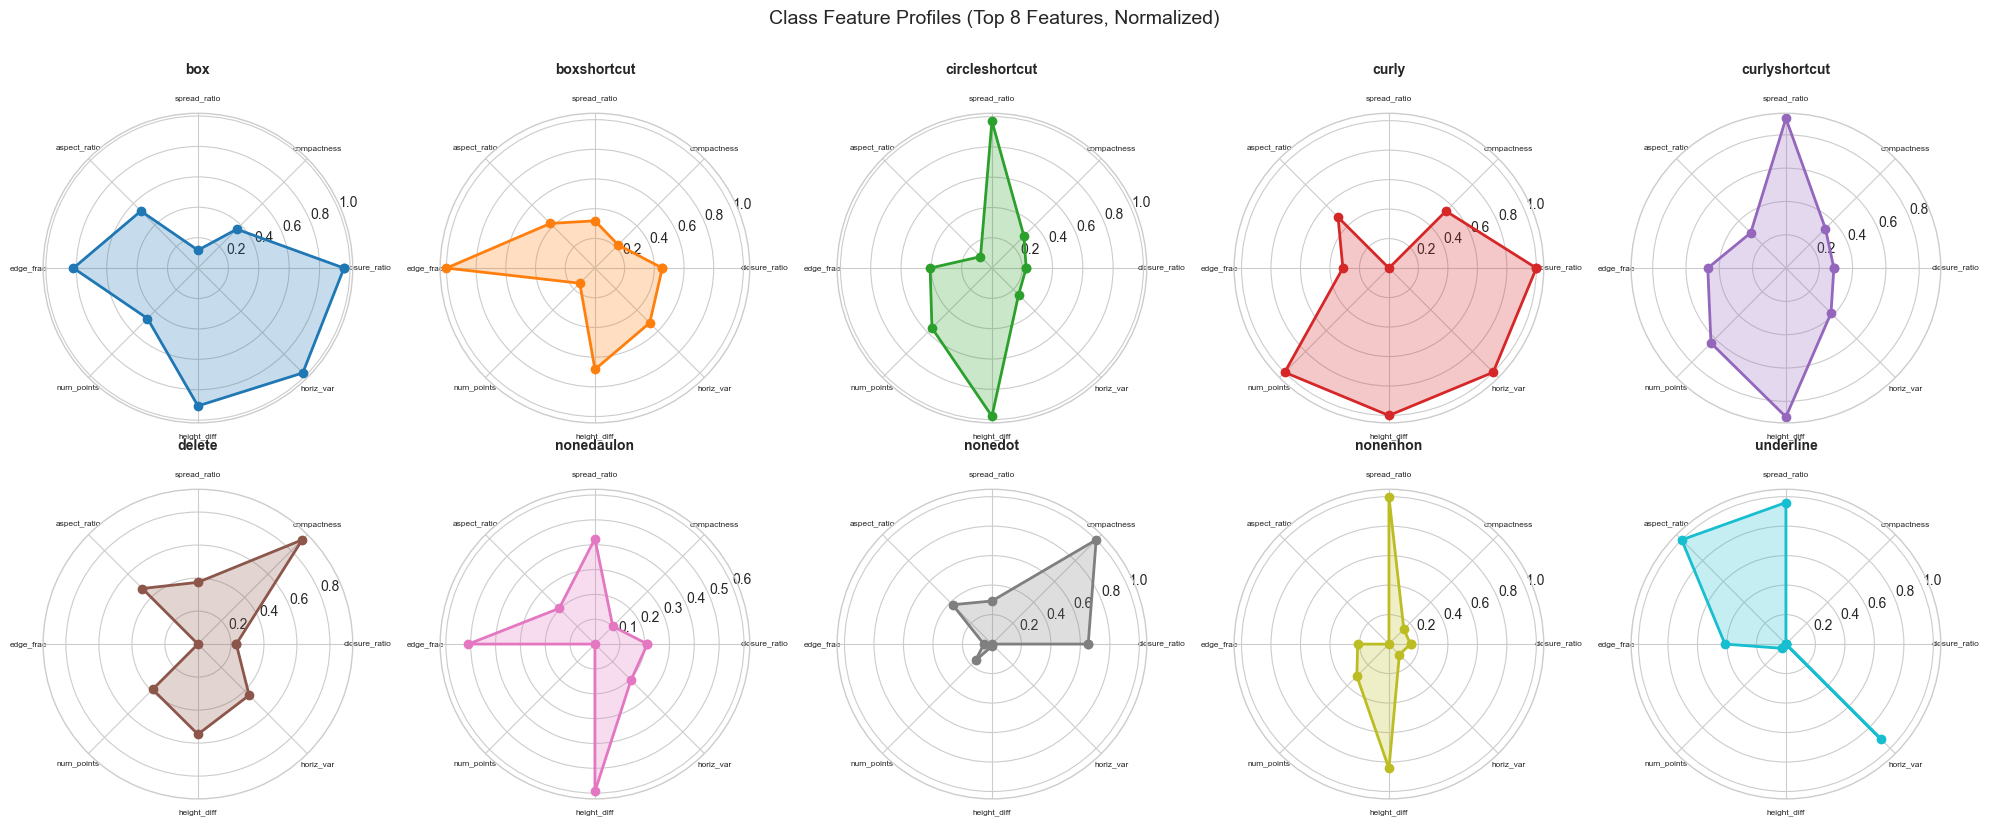

In [101]:
# Radar charts for class profiles
from math import pi

def make_radar_chart(ax, class_name, values, feature_names, color):
    """Create a radar chart for a single class."""
    N = len(feature_names)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    values_plot = values.tolist()
    values_plot += values_plot[:1]
    
    ax.plot(angles, values_plot, 'o-', linewidth=2, color=color, label=class_name)
    ax.fill(angles, values_plot, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_names, size=6)
    ax.set_title(class_name, size=10, fontweight='bold', y=1.1)

# Select top 8 features for radar chart (too many makes it unreadable)
radar_features = combined_df.head(8)['feature'].tolist() if 'combined_df' in dir() else all_features[:8]

# Normalize for radar chart
class_means_radar = features_df.groupby('type')[radar_features].mean()
class_means_norm = (class_means_radar - class_means_radar.min()) / (class_means_radar.max() - class_means_radar.min() + 1e-6)

fig, axes = plt.subplots(2, 5, figsize=(20, 8), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    make_radar_chart(axes[idx], cls, class_means_norm.loc[cls], radar_features, colors[idx])

plt.suptitle('Class Feature Profiles (Top 8 Features, Normalized)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [102]:
# COMPREHENSIVE FEATURE SELECTION ANALYSIS
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score

# Prepare data
X = features_df[all_features].values
y_labels = features_df['type'].values
le = LabelEncoder()
y = le.fit_transform(y_labels)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("=" * 80)
print("FEATURE SELECTION ANALYSIS")
print("=" * 80)

# ============== METHOD 1: ANOVA F-Score ==============
print("\n1. ANOVA F-SCORE (linear class separation)")
selector_anova = SelectKBest(f_classif, k='all')
selector_anova.fit(X_scaled, y)
anova_scores = pd.DataFrame({
    'feature': all_features,
    'anova_score': selector_anova.scores_
}).sort_values('anova_score', ascending=False)

# ============== METHOD 2: Mutual Information ==============
print("2. MUTUAL INFORMATION (non-linear dependencies)")
mi_scores = mutual_info_classif(X_scaled, y, random_state=42)
mi_df = pd.DataFrame({
    'feature': all_features,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

# ============== METHOD 3: Random Forest Importance ==============
print("3. RANDOM FOREST IMPORTANCE (feature interactions)")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_scaled, y)
rf_df = pd.DataFrame({
    'feature': all_features,
    'rf_importance': rf.feature_importances_
}).sort_values('rf_importance', ascending=False)

# ============== METHOD 4: Recursive Feature Elimination ==============
print("4. RECURSIVE FEATURE ELIMINATION (wrapper method)")
lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(lr, n_features_to_select=10, step=1)
rfe.fit(X_scaled, y)
rfe_df = pd.DataFrame({
    'feature': all_features,
    'rfe_rank': rfe.ranking_,
    'rfe_selected': rfe.support_
})

# ============== COMBINE ALL METHODS ==============
combined_df = pd.merge(anova_scores, mi_df, on='feature')
combined_df = pd.merge(combined_df, rf_df, on='feature')
combined_df = pd.merge(combined_df, rfe_df, on='feature')

# Normalize scores to 0-1 range for comparison
for col in ['anova_score', 'mi_score', 'rf_importance']:
    combined_df[f'{col}_norm'] = (combined_df[col] - combined_df[col].min()) / (combined_df[col].max() - combined_df[col].min() + 1e-6)

# Compute combined score (average of normalized scores)
combined_df['combined_score'] = (
    combined_df['anova_score_norm'] + 
    combined_df['mi_score_norm'] + 
    combined_df['rf_importance_norm']
) / 3

# Add RFE bonus for selected features
combined_df['combined_score'] += combined_df['rfe_selected'].astype(float) * 0.1

combined_df = combined_df.sort_values('combined_score', ascending=False)

print("\n" + "=" * 80)
print("FEATURE RANKING (Combined Score)")
print("=" * 80)
print(combined_df[['feature', 'anova_score', 'mi_score', 'rf_importance', 'rfe_selected', 'combined_score']].to_string(index=False))

FEATURE SELECTION ANALYSIS

1. ANOVA F-SCORE (linear class separation)
2. MUTUAL INFORMATION (non-linear dependencies)
3. RANDOM FOREST IMPORTANCE (feature interactions)
4. RECURSIVE FEATURE ELIMINATION (wrapper method)

FEATURE RANKING (Combined Score)
          feature  anova_score  mi_score  rf_importance  rfe_selected  combined_score
    closure_ratio  1845.976863  0.967756       0.101758          True        0.907456
      compactness   652.069529  1.249669       0.146731          True        0.881158
     spread_ratio   883.040653  0.726660       0.068001          True        0.577631
     aspect_ratio   786.537230  0.679187       0.058398          True        0.522627
        edge_frac   521.251349  0.584217       0.070047          True        0.473750
       num_points   284.599314  0.649316       0.068165          True        0.445257
      height_diff   674.194880  0.694403       0.032651          True        0.444496
        horiz_var   279.741061  0.695185       0.043182   

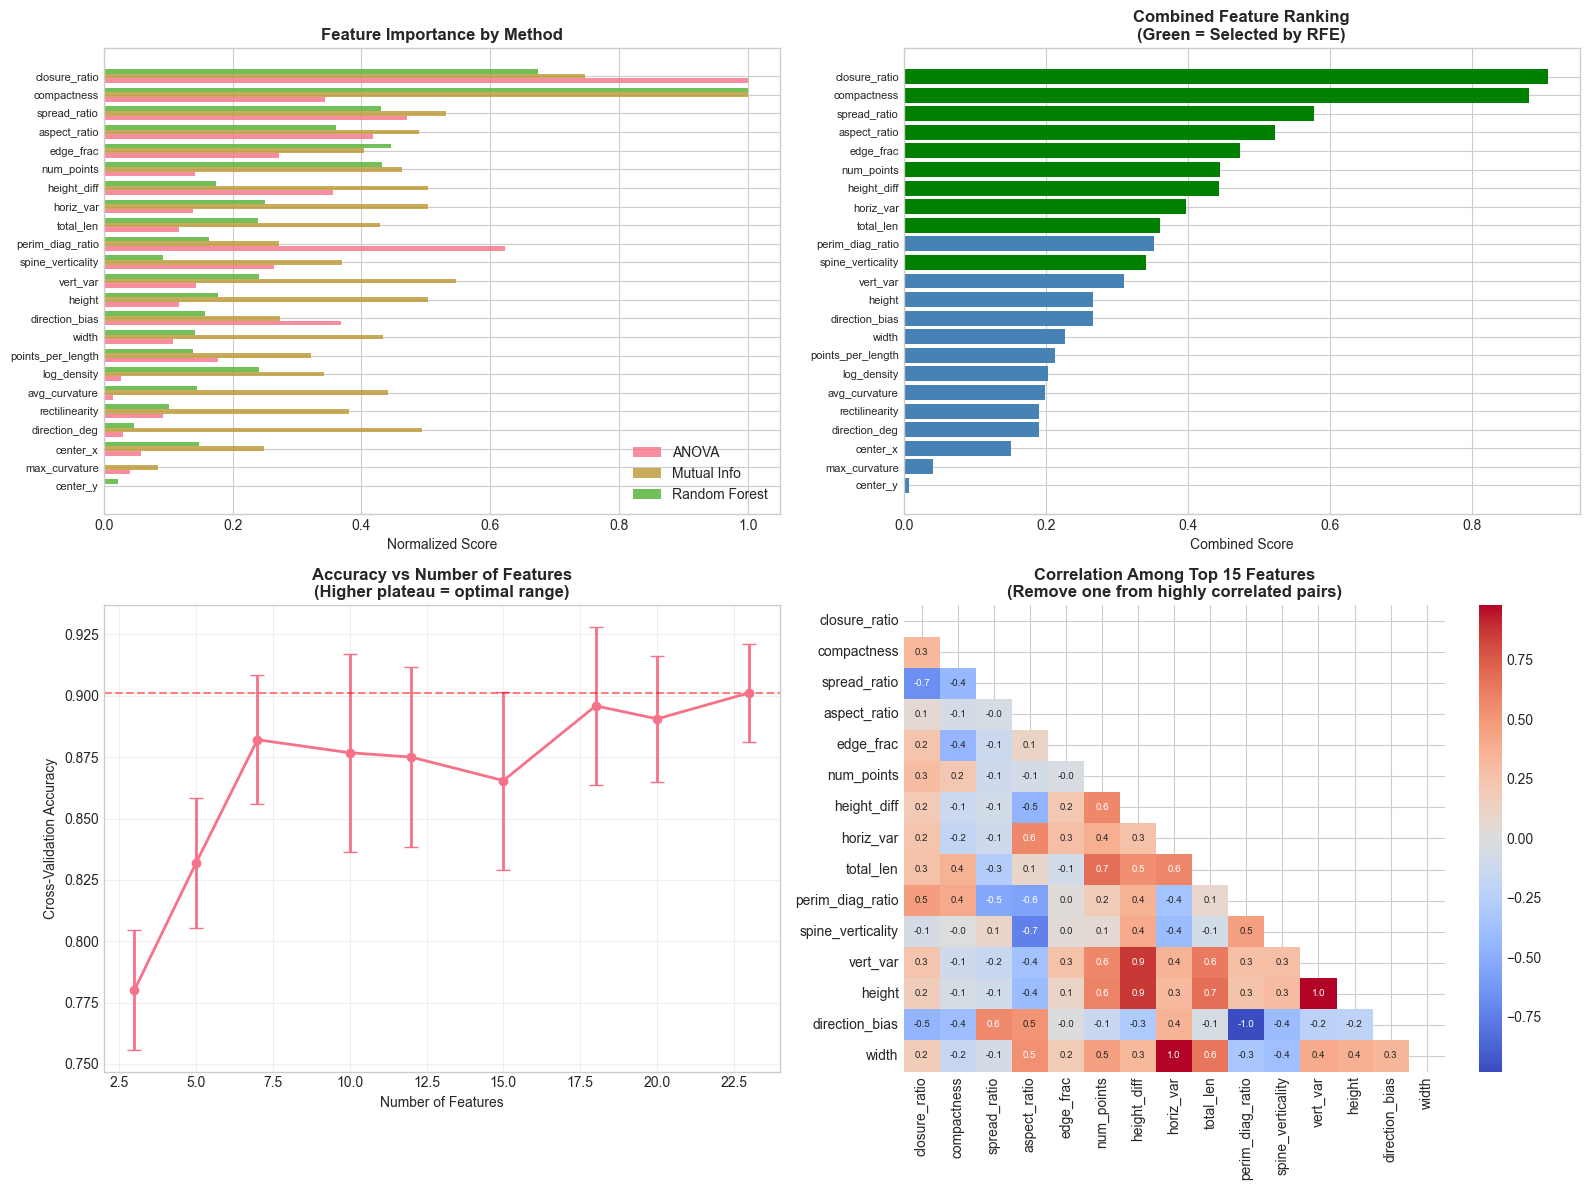


OPTIMAL NUMBER OF FEATURES: 23
Best CV Accuracy: 0.9012 (+/- 0.0200)


In [103]:
# Visualize feature selection results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: All methods comparison
ax = axes[0, 0]
x_pos = np.arange(len(all_features))
width = 0.25
combined_sorted = combined_df.sort_values('combined_score', ascending=True)
ax.barh(x_pos - width, combined_sorted['anova_score_norm'], width, label='ANOVA', alpha=0.8)
ax.barh(x_pos, combined_sorted['mi_score_norm'], width, label='Mutual Info', alpha=0.8)
ax.barh(x_pos + width, combined_sorted['rf_importance_norm'], width, label='Random Forest', alpha=0.8)
ax.set_yticks(x_pos)
ax.set_yticklabels(combined_sorted['feature'], fontsize=8)
ax.set_xlabel('Normalized Score')
ax.set_title('Feature Importance by Method', fontweight='bold')
ax.legend(loc='lower right')

# Plot 2: Combined score ranking
ax = axes[0, 1]
colors_combined = ['green' if s else 'steelblue' for s in combined_sorted['rfe_selected']]
ax.barh(combined_sorted['feature'], combined_sorted['combined_score'], color=colors_combined)
ax.set_xlabel('Combined Score')
ax.set_title('Combined Feature Ranking\n(Green = Selected by RFE)', fontweight='bold')
ax.tick_params(axis='y', labelsize=8)

# Plot 3: Cross-validation accuracy with different number of features
ax = axes[1, 0]
k_values = [3, 5, 7, 10, 12, 15, 18, 20, len(all_features)]
cv_scores = []
top_features_ranked = combined_df.sort_values('combined_score', ascending=False)['feature'].tolist()

for k in k_values:
    selected_features = top_features_ranked[:k]
    X_selected = features_df[selected_features].values
    X_selected_scaled = StandardScaler().fit_transform(X_selected)
    
    scores = cross_val_score(
        RandomForestClassifier(n_estimators=50, random_state=42),
        X_selected_scaled, y, cv=5, scoring='accuracy'
    )
    cv_scores.append({'k': k, 'mean': scores.mean(), 'std': scores.std()})

cv_df = pd.DataFrame(cv_scores)
ax.errorbar(cv_df['k'], cv_df['mean'], yerr=cv_df['std'], marker='o', capsize=5, linewidth=2)
ax.set_xlabel('Number of Features')
ax.set_ylabel('Cross-Validation Accuracy')
ax.set_title('Accuracy vs Number of Features\n(Higher plateau = optimal range)', fontweight='bold')
ax.axhline(y=cv_df['mean'].max(), color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

# Plot 4: Feature correlation with redundancy removal suggestion
ax = axes[1, 1]
# Get top 15 features
top_15 = combined_df.head(15)['feature'].tolist()
corr_top = features_df[top_15].corr()
mask = np.triu(np.ones_like(corr_top, dtype=bool))
sns.heatmap(corr_top, mask=mask, annot=True, fmt='.1f', cmap='coolwarm', 
            center=0, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Among Top 15 Features\n(Remove one from highly correlated pairs)', fontweight='bold')

plt.tight_layout()
plt.show()

# Find optimal k
optimal_k = cv_df.loc[cv_df['mean'].idxmax(), 'k']
print(f"\n{'='*80}")
print(f"OPTIMAL NUMBER OF FEATURES: {int(optimal_k)}")
print(f"Best CV Accuracy: {cv_df['mean'].max():.4f} (+/- {cv_df.loc[cv_df['mean'].idxmax(), 'std']:.4f})")
print(f"{'='*80}")

In [81]:
# Check strokes with very few points
point_threshold = 5
short_strokes = df[df['num_points'] < point_threshold]
print(f"\nStrokes with < {point_threshold} points: {len(short_strokes)}")

if len(short_strokes) > 0:
    print("Distribution by class:")
    print(short_strokes['type'].value_counts())


Strokes with < 5 points: 2
Distribution by class:
type
underline    2
Name: count, dtype: int64


## 9. Key Insights & Recommendations

In [107]:
print("""
============================================================
                  EDA SUMMARY & INSIGHTS
============================================================

1. DATASET OVERVIEW
   - Total samples: {total}
   - Number of classes: {n_classes}
   - Contributors: {n_contrib}
   - Class imbalance ratio: {imbalance:.2f}:1

2. CLASS DISTRIBUTION
   - Dataset is moderately imbalanced
   - Recommendation: Use class weights during training
   - Recommendation: Use stratified splits for train/val/test

3. STROKE CHARACTERISTICS
   - Strokes vary significantly in length and complexity
   - Some classes have distinctive geometric patterns
   - Visual patterns are clear within classes (good for CNN)

4. FEATURE ANALYSIS
   - Most discriminative features: {top_features}
   - Some features are highly correlated (consider removal)
   - Geometric features show class separation (hybrid model justified)

5. DATA QUALITY
   - No missing values
   - Few outliers (can be handled by augmentation)
   - Data appears clean and usable

============================================================
                  RECOMMENDATIONS
============================================================

1. MODEL ARCHITECTURE
   - Use hybrid approach: CNN for images + MLP for features
   - Features add discriminative power beyond images alone

2. DATA PREPROCESSING
   - Normalize strokes to [0, 1] range
   - Render to consistent image size (136x136)
   - Extract 10D geometric features

3. DATA AUGMENTATION
   - Apply rotation, shear, scale transforms
   - Use horizontal flipping
   - Augmentation will help with class imbalance

4. TRAINING STRATEGY
   - Use class weights for imbalanced classes
   - Use early stopping to prevent overfitting
   - Use stratified cross-validation

============================================================
""".format(
    total=len(df),
    n_classes=df['type'].nunique(),
    n_contrib=df['contributor'].nunique(),
    imbalance=imbalance_ratio,
    top_features=', '.join(f_df.index[:3].tolist()),
))


                  EDA SUMMARY & INSIGHTS

1. DATASET OVERVIEW
   - Total samples: 2825
   - Number of classes: 10
   - Contributors: 4
   - Class imbalance ratio: 2.28:1

2. CLASS DISTRIBUTION
   - Dataset is moderately imbalanced
   - Recommendation: Use class weights during training
   - Recommendation: Use stratified splits for train/val/test

3. STROKE CHARACTERISTICS
   - Strokes vary significantly in length and complexity
   - Some classes have distinctive geometric patterns
   - Visual patterns are clear within classes (good for CNN)

4. FEATURE ANALYSIS
   - Most discriminative features: closure_ratio, perim_diag_ratio, spread_ratio
   - Some features are highly correlated (consider removal)
   - Geometric features show class separation (hybrid model justified)

5. DATA QUALITY
   - No missing values
   - Few outliers (can be handled by augmentation)
   - Data appears clean and usable

                  RECOMMENDATIONS

1. MODEL ARCHITECTURE
   - Use hybrid approach: CNN for i

---

## Next Steps

1. **Feature Engineering**: Proceed to compute the full 10D feature vector (see `01_training_pipeline.ipynb`)
2. **Model Comparison**: Compare different architectures (see `02_model_comparison.ipynb`)
3. **Training**: Train the best model with full augmentation